In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter

#load data
df = pd.read_csv('persons_of_concern.csv')

#information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61211 entries, 0 to 61210
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   Year                                              61211 non-null  int64 
 1   Country of Asylum                                 61211 non-null  object
 2   Country of Origin                                 61211 non-null  object
 3   Country of Asylum ISO                             61211 non-null  object
 4   Country of Origin ISO                             61211 non-null  object
 5   Refugees                                          61211 non-null  int64 
 6   Asylum-seekers                                    61211 non-null  int64 
 7   IDPs                                              61211 non-null  int64 
 8   Other people in need of international protection  61211 non-null  int64 
 9   Stateless persons           

In [2]:
df.head()

,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Refugees,Asylum-seekers,IDPs,Other people in need of international protection,Stateless persons,Host community,Others of concern
0,2015,Afghanistan,Afghanistan,AFG,AFG,0,0,1174306,0,0,0,150317
1,2015,Egypt,Afghanistan,EGY,AFG,0,33,0,0,0,0,0
2,2015,Argentina,Afghanistan,ARG,AFG,5,0,0,0,0,0,0
3,2015,Australia,Afghanistan,AUS,AFG,7785,1422,0,0,0,0,0
4,2015,Austria,Afghanistan,AUT,AFG,17458,24267,0,0,0,0,0


In [3]:
#unique country names
unique_countries = df['Country of Asylum'].unique()
num_countries = df['Country of Asylum'].nunique()
print(num_countries)
print(unique_countries)

190
['Afghanistan' 'Egypt' 'Argentina' 'Australia' 'Austria' 'Azerbaijan'
 'Belgium' 'Belarus' 'Brazil' 'Bulgaria' 'Canada' 'China' 'Chile'
 'Colombia' 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Dominican Rep.' 'Ecuador'
 'Estonia' 'Fiji' 'Finland' 'France'
 'United Kingdom of Great Britain and Northern Ireland' 'Georgia'
 'Germany' 'Greece' 'China, Hong Kong SAR' 'Croatia' 'Hungary' 'Iceland'
 'India' 'Indonesia' 'Ireland' 'Iran (Islamic Rep. of)' 'Iraq' 'Italy'
 'Jordan' 'Japan' 'Kazakhstan' 'Kenya' 'Kyrgyzstan' 'Rep. of Korea'
 'Lebanon' 'Liechtenstein' 'Sri Lanka' 'Lithuania' 'Luxembourg' 'Latvia'
 'Rep. of Moldova' 'Mexico' 'Malaysia' 'Mongolia' 'Nepal'
 'Netherlands (Kingdom of the)' 'Nigeria' 'Norway' 'Nauru' 'New Zealand'
 'Pakistan' 'Panama' 'Philippines' 'Papua New Guinea' 'Poland' 'Portugal'
 'Romania' 'South Africa' 'Russian Federation' 'Senegal' 'Spain'
 'Serbia and Kosovo: S/RES/1244 (1999)' 'Sudan' 'Slovakia' 'Slovenia'
 'Sweden' 'Switzerland' 'Syrian Arab Rep.' 'Thailand' 'Ta

In [4]:
#clean/normalize country names, such as Netherlands (Kingdom of the)
##define name cleaner
name_cleaner = {
    'Netherlands (Kingdom of the)': 'Netherlands',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'Iran (Islamic Republic of)': 'Iran',
    'Syrian Arab Rep.': 'Syria',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Dem. Rep. of the Congo': 'DR Congo'
}

#replace names in columns
df['Country of Asylum'] = df['Country of Asylum'].replace(name_cleaner)
if 'Country of Origin' in df.columns:
    df['Country of Origin'] = df['Country of Origin'].replace(name_cleaner)

#doublecheck
print(df[df['Country of Asylum'] == 'Netherlands']['Country of Asylum'].unique())
print(df[df['Country of Origin'] == 'Venezuela']['Country of Origin'].unique())

['Netherlands']
['Venezuela']


In [5]:
#select columns
selected_columns = ['Year', 'Country of Asylum', 'Country of Origin', 'Country of Asylum ISO', 'Country of Origin ISO', 'Refugees', 'Asylum-seekers', 'Total']

#define list of EU countries (excluding UK, because of Brexit in 2021)
eu_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 
    'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 
    'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 
    'Slovenia', 'Spain', 'Sweden'
]

#filter
df_eu = df[(df['Country of Asylum'].isin(eu_countries)) & (df['Year'].between(2015, 2025))].copy()

#define total
df_eu['Total'] = df_eu['Refugees'] + df_eu['Asylum-seekers']

#select columns
df_eu = df_eu[selected_columns]

#show
df_eu.head()

,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Refugees,Asylum-seekers,Total
4,2015,Austria,Afghanistan,AUT,AFG,17458,24267,41725
6,2015,Belgium,Afghanistan,BEL,AFG,2934,1643,4577
9,2015,Bulgaria,Afghanistan,BGR,AFG,197,3241,3438
15,2015,Cyprus,Afghanistan,CYP,AFG,7,14,21
16,2015,Czechia,Afghanistan,CZE,AFG,234,6,240


In [6]:
#compare top countries 2015 vs. 2025
##clean/normalize column names
df.columns = df.columns.str.strip()

#year 2015
df_eu = df[
    (df['Country of Asylum'].isin(eu_countries)) &
    (df['Year'] == 2015)
].copy()

#select column 'Refugees' from the dataframe
df_eu['Refugees'] = pd.to_numeric(df_eu['Refugees'], errors='coerce').fillna(0)

#convert every value in the column to a numeric type
##replace NaN with '0'
df_eu['Asylum-seekers'] = pd.to_numeric(df_eu['Asylum-seekers'], errors='coerce').fillna(0)

#sum (Refugees + Asylum-seekers)
df_eu['Total'] = df_eu['Refugees'] + df_eu['Asylum-seekers']

#groupby country
df_totals_per_country = df_eu.groupby('Country of Asylum')[['Refugees', 'Asylum-seekers', 'Total']].sum().reset_index()

#sort numbers
df_totals_per_country = df_totals_per_country.sort_values(by='Total', ascending=False)

#print
print("CUMULATIVE VOLUMES PER EU COUNTRY (as of 2015):")
print("-" * 75)
print(f"{'Country of Asylum':<20} | {'Refugees':<15} | {'Asylum Seekers':<15} | {'Total':<15}")
print("-" * 75)

for idx, row in df_totals_per_country.iterrows():
    print(f"{row['Country of Asylum']:<20} | {row['Refugees']:<15,.0f} | {row['Asylum-seekers']:<15,.0f} | {row['Total']:<15,.0f}")

CUMULATIVE VOLUMES PER EU COUNTRY (as of 2015):
---------------------------------------------------------------------------
Country of Asylum    | Refugees        | Asylum Seekers  | Total          
---------------------------------------------------------------------------
Germany              | 316,098         | 420,570         | 736,668        
France               | 273,117         | 63,043          | 336,160        
Sweden               | 169,516         | 157,017         | 326,533        
Italy                | 118,036         | 60,135          | 178,171        
Austria              | 72,198          | 80,060          | 152,258        
Netherlands          | 88,518          | 28,030          | 116,548        
Belgium              | 35,302          | 35,996          | 71,298         
Greece               | 24,831          | 26,122          | 50,953         
Hungary              | 4,383           | 36,671          | 41,054         
Finland              | 12,692          | 24,340   

In [7]:
#latest data: year 2025
df_eu = df[
    (df['Country of Asylum'].isin(eu_countries)) &
    (df['Year'] == 2025)
].copy()

#select column 'Refugees' from the dataframe
df_eu['Refugees'] = pd.to_numeric(df_eu['Refugees'], errors='coerce').fillna(0)

#convert every value in the column to a numeric type
##replace NaN with '0'
df_eu['Asylum-seekers'] = pd.to_numeric(df_eu['Asylum-seekers'], errors='coerce').fillna(0)

#sum (Refugees + Asylum-seekers)
df_eu['Total'] = df_eu['Refugees'] + df_eu['Asylum-seekers']

#groupby country
df_totals_per_country = df_eu.groupby('Country of Asylum')[['Refugees', 'Asylum-seekers', 'Total']].sum().reset_index()

#sort numbers
df_totals_per_country = df_totals_per_country.sort_values(by='Total', ascending=False)

#print
print("CUMULATIVE VOLUMES PER EU COUNTRY (as of 2025):")
print("-" * 75)
print(f"{'Country of Asylum':<20} | {'Refugees':<15} | {'Asylum Seekers':<15} | {'Total':<15}")
print("-" * 75)

for idx, row in df_totals_per_country.iterrows():
    print(f"{row['Country of Asylum']:<20} | {row['Refugees']:<15,.0f} | {row['Asylum-seekers']:<15,.0f} | {row['Total']:<15,.0f}")

CUMULATIVE VOLUMES PER EU COUNTRY (as of 2025):
---------------------------------------------------------------------------
Country of Asylum    | Refugees        | Asylum Seekers  | Total          
---------------------------------------------------------------------------
Germany              | 2,655,191       | 297,503         | 2,952,694      
Poland               | 990,469         | 13,848          | 1,004,317      
France               | 788,419         | 85,227          | 873,646        
Spain                | 511,079         | 248,715         | 759,794        
Italy                | 192,914         | 234,144         | 427,058        
Czechia              | 395,559         | 993             | 396,552        
Netherlands          | 283,935         | 49,662          | 333,597        
Austria              | 286,651         | 22,014          | 308,665        
Belgium              | 186,393         | 58,725          | 245,118        
Romania              | 206,671         | 316      

In [8]:
#top 10 as of 2025
eu_countries_10 = ['Germany', 'Poland', 'France', 'Spain', 'Italy', 'Czechia', 'Netherlands', 'Austria', 'Belgium', 'Romania']

#new df
df_eu_10 = df_eu[df_eu['Country of Asylum'].isin(eu_countries_10)].copy()

#reset index
df_eu_10 = df_eu_10.reset_index(drop=True)

df_eu = df[df['Country of Asylum'].isin(eu_countries_10) & (df['Year'] == 2025)].copy()

#select column 'Refugees' from the dataframe
df_eu['Refugees'] = pd.to_numeric(df_eu['Refugees'], errors='coerce').fillna(0)

#convert every value in the column to a numeric type
##replace NaN with '0'
df_eu['Asylum-seekers'] = pd.to_numeric(df_eu['Asylum-seekers'], errors='coerce').fillna(0)

#sum (Refugees + Asylum-seekers)
df_eu['Total'] = df_eu['Refugees'] + df_eu['Asylum-seekers']

#group by country
df_totals_per_country = df_eu.groupby('Country of Asylum')[['Refugees', 'Asylum-seekers', 'Total']].sum().reset_index()

#sort numbers
df_totals_per_country = df_totals_per_country.sort_values(by='Total', ascending=False)

#print
print("Cumulative Volumes Top 10 EU Countries (2025):")
print("-" * 75)
print(f"{'Country of Asylum':<20} | {'Refugees':<15} | {'Asylum Seekers':<15} | {'Total':<15}")
print("-" * 75)

for idx, row in df_totals_per_country.iterrows():
    print(f"{row['Country of Asylum']:<20} | {row['Refugees']:<15,.0f} | {row['Asylum-seekers']:<15,.0f} | {row['Total']:<15,.0f}")

Cumulative Volumes Top 10 EU Countries (2025):
---------------------------------------------------------------------------
Country of Asylum    | Refugees        | Asylum Seekers  | Total          
---------------------------------------------------------------------------
Germany              | 2,655,191       | 297,503         | 2,952,694      
Poland               | 990,469         | 13,848          | 1,004,317      
France               | 788,419         | 85,227          | 873,646        
Spain                | 511,079         | 248,715         | 759,794        
Italy                | 192,914         | 234,144         | 427,058        
Czechia              | 395,559         | 993             | 396,552        
Netherlands          | 283,935         | 49,662          | 333,597        
Austria              | 286,651         | 22,014          | 308,665        
Belgium              | 186,393         | 58,725          | 245,118        
Romania              | 206,671         | 316       

In [9]:
#show head
df.head()

,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Refugees,Asylum-seekers,IDPs,Other people in need of international protection,Stateless persons,Host community,Others of concern
0,2015,Afghanistan,Afghanistan,AFG,AFG,0,0,1174306,0,0,0,150317
1,2015,Egypt,Afghanistan,EGY,AFG,0,33,0,0,0,0,0
2,2015,Argentina,Afghanistan,ARG,AFG,5,0,0,0,0,0,0
3,2015,Australia,Afghanistan,AUS,AFG,7785,1422,0,0,0,0,0
4,2015,Austria,Afghanistan,AUT,AFG,17458,24267,0,0,0,0,0


In [10]:
#select columns
selected_columns = ['Year', 'Country of Asylum', 'Country of Origin', 'Country of Asylum ISO', 'Country of Origin ISO', 'Refugees', 'Asylum-seekers']

#in df_eu
df_eu = df[(df['Country of Asylum'].isin(eu_countries_10)) & (df['Year'].between(2015, 2025))][selected_columns].copy()

#show
df_eu.head(5)

,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Refugees,Asylum-seekers
4,2015,Austria,Afghanistan,AUT,AFG,17458,24267
6,2015,Belgium,Afghanistan,BEL,AFG,2934,1643
16,2015,Czechia,Afghanistan,CZE,AFG,234,6
23,2015,France,Afghanistan,FRA,AFG,4397,2110
26,2015,Germany,Afghanistan,DEU,AFG,30026,42602


In [11]:
#clean names, such as Netherlands (Kingdom of the)
##define name cleaner
name_cleaner = {
    'Netherlands (Kingdom of the)': 'Netherlands',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'Iran (Islamic Republic of)': 'Iran',
    'Syrian Arab Republic': 'Syria',
    'Venezuela (Bolivarian Republic of)' : 'Venezuela'
}

#replace names in columns
df['Country of Asylum'] = df['Country of Asylum'].replace(name_cleaner)
if 'Country of Origin' in df.columns:
    df['Country of Origin'] = df['Country of Origin'].replace(name_cleaner)

#doublecheck
print(df[df['Country of Asylum'] == 'Netherlands']['Country of Asylum'].unique())

['Netherlands']


In [12]:
#filter eu countries
df_eu = df[df['Country of Asylum'].isin(eu_countries)]

#show eu data
numbers_eu_daten = df_eu.shape[0]
unique_eu_countries = df_eu['Country of Asylum'].nunique()

print(f'Number of EU Countries: {unique_eu_countries}')

#show top 10 in terms of frequency
print(df_eu['Country of Asylum'].value_counts().head(10))

Number of EU Countries: 27
Country of Asylum
Germany        1691
France         1443
Sweden         1297
Italy          1247
Belgium        1242
Netherlands    1190
Spain          1175
Ireland        1092
Austria         983
Greece          915
Name: count, dtype: int64


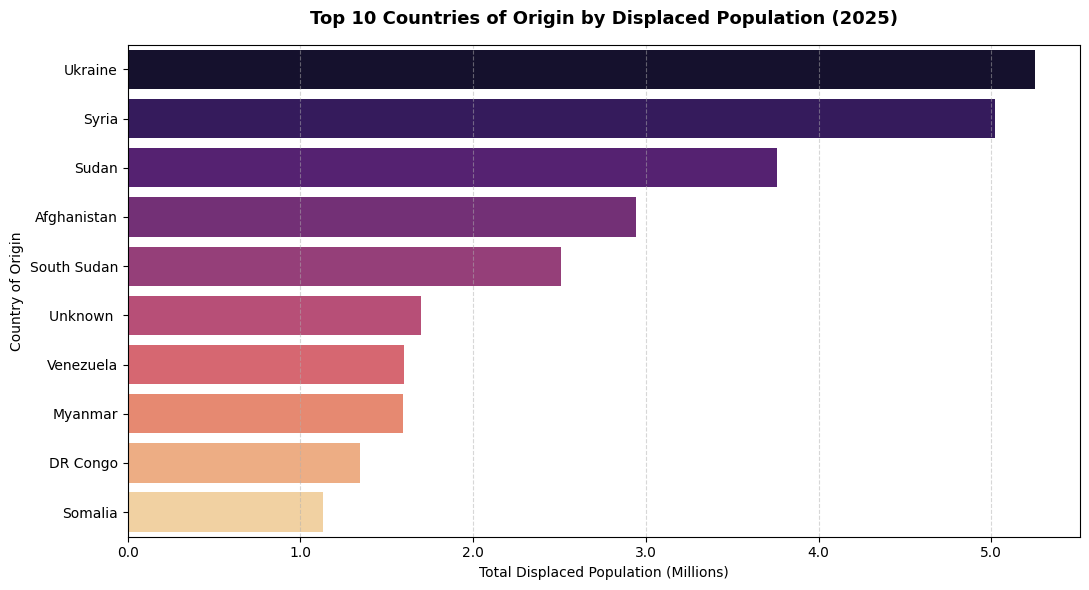

In [13]:
#countries of origin - top ten
##clean column names
df.columns = df.columns.str.strip()

#ensure numeric format
df['Refugees'] = pd.to_numeric(df['Refugees'], errors='coerce').fillna(0)
df['Asylum-seekers'] = pd.to_numeric(df['Asylum-seekers'], errors='coerce').fillna(0)

#combine total displaced stock
df['Total_Displaced'] = df['Refugees'] + df['Asylum-seekers']

#filter one year only to avoid double counting
df_origin_2025 = df[df['Year'] == 2025].copy()

#aggregate by country of origin
df_top_origin = (
    df_origin_2025
    .groupby('Country of Origin')['Total_Displaced']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

#plot
plt.figure(figsize=(11,6))

#sns.barplot
sns.barplot(
    data=df_top_origin,
    y='Country of Origin',
    x='Total_Displaced',
    hue='Country of Origin',
    palette='magma',
    legend=False
)

#layout
plt.title('Top 10 Countries of Origin by Displaced Population (2025)', fontsize=13, pad=15, weight='bold')
plt.xlabel('Total Displaced Population')
plt.ylabel('Country of Origin')

plt.grid(axis='x', linestyle='--', alpha=0.5)

#format axis
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}'))
plt.xlabel('Total Displaced Population (Millions)')


plt.tight_layout()

#save
plt.savefig("Figure 1: Top 10 Countries of Origin.png", dpi=300, bbox_inches="tight")

#show plot
plt.show()

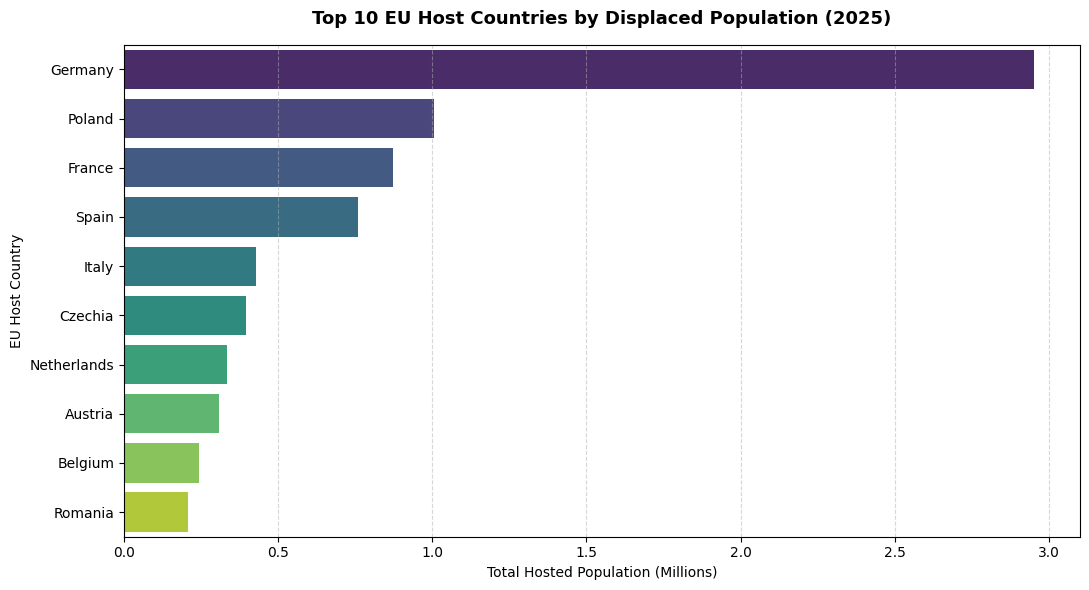

In [14]:
#top 10 destinations
##clean column names
df.columns = df.columns.str.strip()

# ensure numeric format
df['Refugees'] = pd.to_numeric(df['Refugees'], errors='coerce').fillna(0)
df['Asylum-seekers'] = pd.to_numeric(df['Asylum-seekers'], errors='coerce').fillna(0)

#combine total displaced stock
df['Total_Displaced'] = df['Refugees'] + df['Asylum-seekers']

#filter one year only to avoid double counting
df_2025 = df[df['Year'] == 2025].copy()

#list of EU member states
eu_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus',
    'Czechia', 'Denmark', 'Estonia', 'Finland', 'France',
    'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy',
    'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
    'Netherlands', 'Poland', 'Portugal', 'Romania',
    'Slovakia', 'Slovenia', 'Spain', 'Sweden'
]

#aggregate by host country
df_top_host = (
    df_2025[df_2025['Country of Asylum'].isin(eu_countries)]
    .groupby('Country of Asylum')['Total_Displaced']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

#plot
plt.figure(figsize=(11,6))

sns.barplot(
    data=df_top_host,
    y='Country of Asylum',
    x='Total_Displaced',
    hue='Country of Asylum',
    palette='viridis',
    legend=False
)

#layout
plt.title(
    'Top 10 EU Host Countries by Displaced Population (2025)',
    fontsize=13, pad=15,
    weight='bold'
)

plt.xlabel('Total Hosted Population (Millions)')
plt.ylabel('EU Host Country')

plt.grid(axis='x', linestyle='--', alpha=0.5)

#format axis
ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.1f}')
)

plt.tight_layout()

#save
plt.savefig(
    "Figure 2 - Top 10 EU Host Countries.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

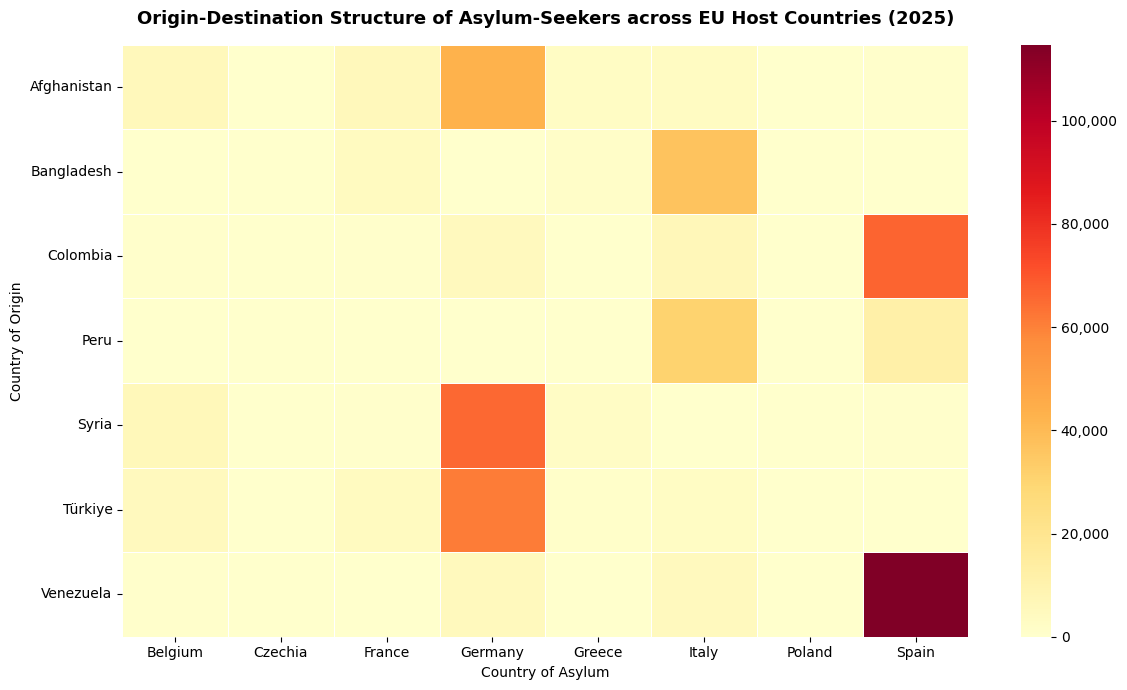

In [15]:
#selected EU host countries - top 8
eu_countries_8 = [
    'Germany', 'Poland', 'France', 'Spain', 'Italy', 'Czechia', 'Belgium', 'Greece'
]

#filter 2025 + EU host countries
df_heat = df[
    (df['Country of Asylum'].isin(eu_countries_8)) &
    (df['Year'] == 2025)
].copy()

#numeric conversion
df_heat['Asylum-seekers'] = pd.to_numeric(
    df_heat['Asylum-seekers'],
    errors='coerce'
).fillna(0)

#find top 7 origin countries by asylum seekers
top_origins = (
    df_heat.groupby('Country of Origin')['Asylum-seekers']
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

#keep only top origins
df_heat = df_heat[df_heat['Country of Origin'].isin(top_origins)]

#create matrix
heatmap_data = df_heat.pivot_table(
    index='Country of Origin',
    columns='Country of Asylum',
    values='Asylum-seekers',
    aggfunc='sum',
    fill_value=0
)

#plot
plt.figure(figsize=(12,7))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'format': ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')}
)

#layout
plt.title(
    'Origin-Destination Structure of Asylum-Seekers across EU Host Countries (2025)',
    fontsize=13,
    weight='bold',
    pad=15
)

plt.xlabel('Country of Asylum')
plt.ylabel('Country of Origin')

plt.tight_layout()

#save
plt.savefig(
    "Figure 3 - Origin-Destination Structure.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

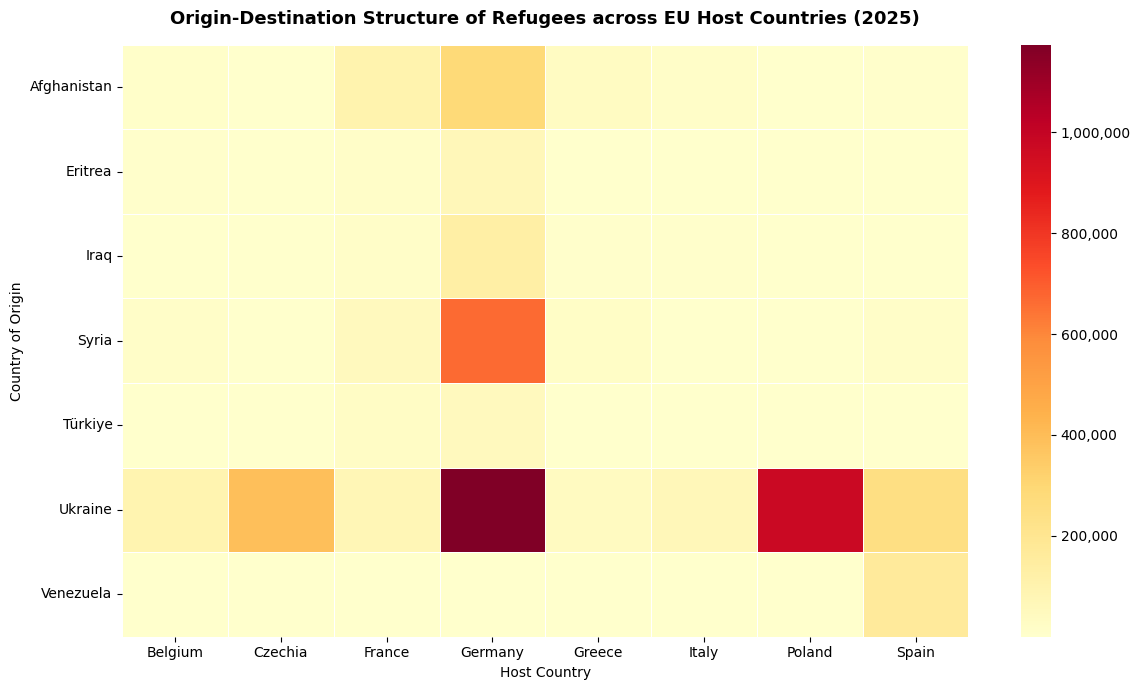

In [16]:
#selected EU host countries - top 8
eu_countries_8 = [
    'Germany', 'Poland', 'France', 'Spain', 'Italy', 'Czechia', 'Belgium', 'Greece'
]

#filter 2025 + EU host countries
df_heat = df[
    (df['Country of Asylum'].isin(eu_countries_8)) &
    (df['Year'] == 2025)
].copy()

#numeric conversion
df_heat['Refugees'] = pd.to_numeric(
    df_heat['Refugees'],
    errors='coerce'
).fillna(0)

#find top 7 origin countries by asylum seekers
top_origins = (
    df_heat.groupby('Country of Origin')['Refugees']
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

#keep only top origins
df_heat = df_heat[df_heat['Country of Origin'].isin(top_origins)]

#create matrix
heatmap_data = df_heat.pivot_table(
    index='Country of Origin',
    columns='Country of Asylum',
    values='Refugees',
    aggfunc='sum',
    fill_value=0
)

#plot
plt.figure(figsize=(12,7))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'format': ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')}
)

#y-axis
plt.yticks(rotation=0)

#layout
plt.title(
    'Origin-Destination Structure of Refugees across EU Host Countries (2025)',
    fontsize=13,
    weight='bold',
    pad=15
)

plt.xlabel('Host Country')
plt.ylabel('Country of Origin')

plt.tight_layout()

#save
plt.savefig(
    "Figure 4 - Origin-Destination Strucuture Refugees.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

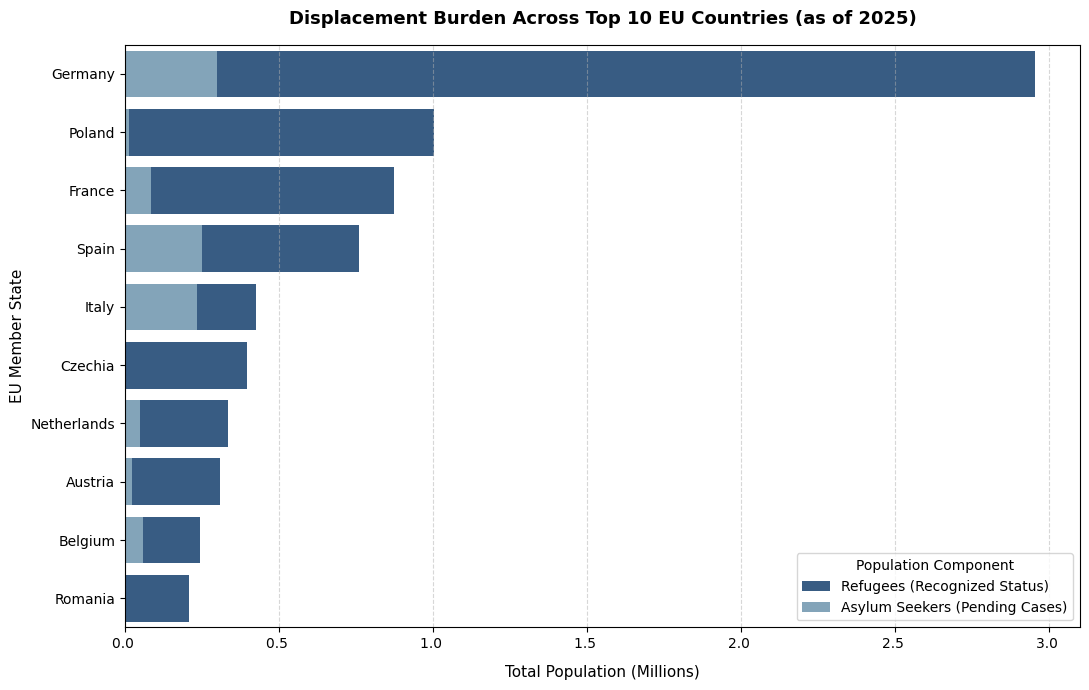

In [17]:
#displacement burden across Top 10 EU countries
##define year
df_single_year = df[
    (df['Country of Asylum'].isin(eu_countries_10)) &
    (df['Year'] == 2025)
].copy()

#define datatype and replace NaN with 0
df_single_year['Refugees'] = pd.to_numeric(
    df_single_year['Refugees'],
    errors='coerce'
).fillna(0)

df_single_year['Asylum-seekers'] = pd.to_numeric(
    df_single_year['Asylum-seekers'],
    errors='coerce'
).fillna(0)

#aggregate numbers
df_plot = (
    df_single_year.groupby('Country of Asylum')[['Refugees', 'Asylum-seekers']]
    .sum()
    .reset_index()
)

#total and sort values
df_plot['Total'] = (
    df_plot['Refugees'] +
    df_plot['Asylum-seekers']
)

df_plot = df_plot.sort_values(
    by='Total',
    ascending=False
)

#keep only top 10 countries
df_plot = df_plot.head(10)

#size
plt.figure(figsize=(11, 7))

#stacked bar chart
sns.barplot(
    data=df_plot,
    y='Country of Asylum',
    x='Total',
    label='Refugees (Recognized Status)',
    color='#2b5c8f'
)

sns.barplot(
    data=df_plot,
    y='Country of Asylum',
    x='Asylum-seekers',
    label='Asylum Seekers (Pending Cases)',
    color='#7aa6c2'
)

#layout
plt.title(
    'Displacement Burden Across Top 10 EU Countries (as of 2025)',
    fontsize=13,
    pad=15,
    weight='bold'
)

plt.xlabel(
    'Total Population (Millions)',
    fontsize=11,
    labelpad=10
)

plt.ylabel(
    'EU Member State',
    fontsize=11
)

#grid
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

#format x-axis
formatter = FuncFormatter(lambda x, _: f'{x/1_000_000:.1f} ')
plt.gca().xaxis.set_major_formatter(formatter)

#legend
plt.legend(
    title='Population Component',
    loc='lower right',
    frameon=True
)

#layout
plt.tight_layout()

#save
plt.savefig(
    "Figure 5 - Displacement Burden Top 10.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

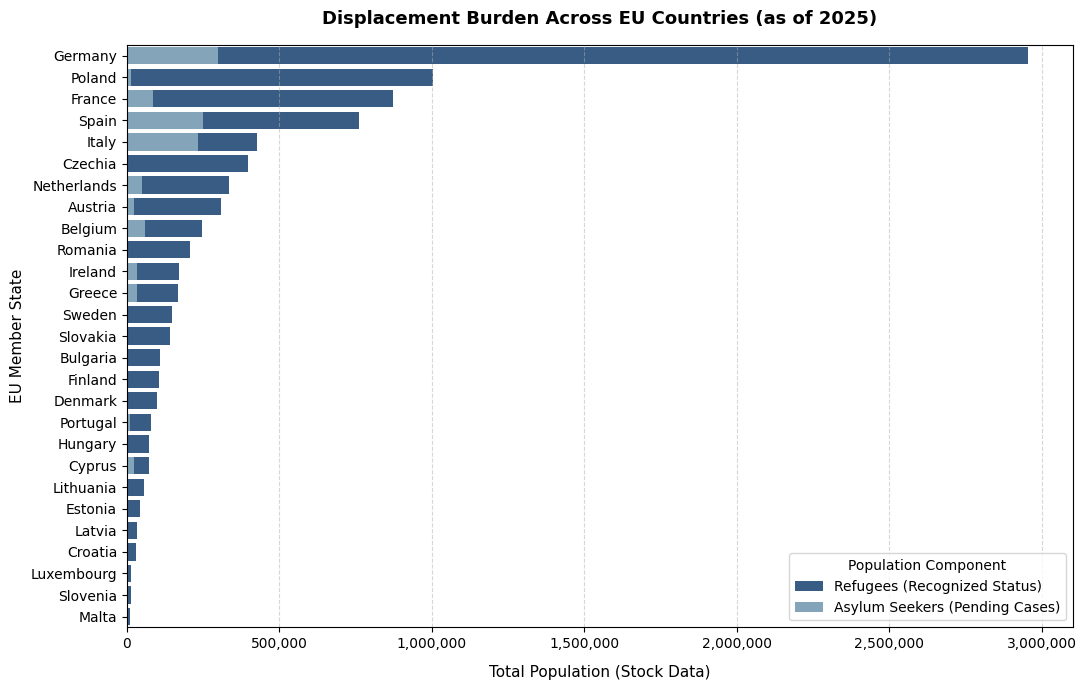

In [18]:
#displacement burden across EU-27 countries
##define year
df_single_year = df[(df['Country of Asylum'].isin(eu_countries)) & (df['Year'] == 2025)].copy()

#define datatyp and replace NaN with '0' in df
df_single_year['Refugees'] = pd.to_numeric(df_single_year['Refugees'], errors='coerce').fillna(0)
df_single_year['Asylum-seekers'] = pd.to_numeric(df_single_year['Asylum-seekers'], errors='coerce').fillna(0)

#aggregate numbers
df_plot = df_single_year.groupby('Country of Asylum')[['Refugees', 'Asylum-seekers']].sum().reset_index()

#total and sort values
df_plot['Total'] = df_plot['Refugees'] + df_plot['Asylum-seekers']
df_plot = df_plot.sort_values(by='Total', ascending=False)

#size
plt.figure(figsize=(11, 7))

#stacked bar chart
sns.barplot(data=df_plot, y='Country of Asylum', x='Total', label='Refugees (Recognized Status)', color='#2b5c8f')
sns.barplot(data=df_plot, y='Country of Asylum', x='Asylum-seekers', label='Asylum Seekers (Pending Cases)', color='#7aa6c2')

#layout
plt.title('Displacement Burden Across EU Countries (as of 2025)', fontsize=13, pad=15, weight='bold')
plt.xlabel('Total Population (Stock Data)', fontsize=11, labelpad=10)
plt.ylabel('EU Member State', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)

#format axes
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

#legend
plt.legend(title='Population Component', loc='lower right', frameon=True)
plt.tight_layout()

#save
plt.savefig(
    "Figure 6 - Displacement Burden EU-27.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

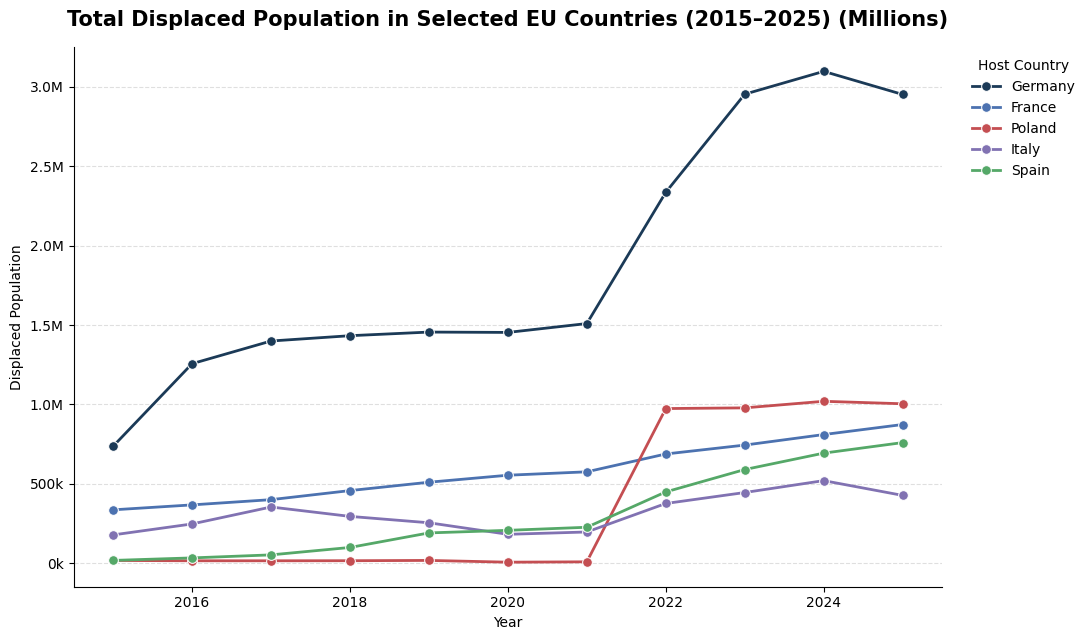

In [19]:
#total displace top EU host countries
eu_countries_5 = ['Germany', 'France', 'Poland', 'Spain', 'Italy'] 

#filter data
df_eu = df[
    (df['Country of Asylum'].isin(eu_countries_5)) &
    (df['Year'] >= 2015)
].copy()

#numeric format
df_eu['Refugees'] = pd.to_numeric(
    df_eu['Refugees'],
    errors='coerce'
).fillna(0)

df_eu['Asylum-seekers'] = pd.to_numeric(
    df_eu['Asylum-seekers'],
    errors='coerce'
).fillna(0)

#total displaced
df_eu['Total_Displaced'] = (
    df_eu['Asylum-seekers'] +
    df_eu['Refugees']
)

#group by
df_grouped = (
    df_eu
    .groupby(['Year', 'Country of Asylum'])['Total_Displaced']
    .sum()
    .reset_index()
)

#order legend by size
legend_order = (
    df_grouped
    .groupby('Country of Asylum')['Total_Displaced']
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

#color
custom_palette = {
    'Germany': '#1B3A57',   
     'Poland': '#C44E52',    
    'France': '#4C72B0',    
    'Spain': '#55A868',    
    'Italy': '#8172B2'      
}

#plot
plt.figure(figsize=(11, 6.5))

ax = sns.lineplot(
    data=df_grouped,
    x='Year',
    y='Total_Displaced',
    hue='Country of Asylum',
    hue_order=legend_order,
    palette=custom_palette,
    linewidth=2.0,
    marker='o',
    markersize=7
)

#layout
plt.title(
    'Total Displaced Population in Selected EU Countries (2015–2025) (Millions)',
    fontsize=15,
    weight='bold',
    pad=15
)

plt.ylabel('Displaced Population')
plt.xlabel('Year')

#grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

#remove borders
sns.despine()

# y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))

#legend outside plot
plt.legend(
    title='Host Country',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()

#save figure
plt.savefig(
    "Figure 7 - Total Displaced Population EU Countries.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

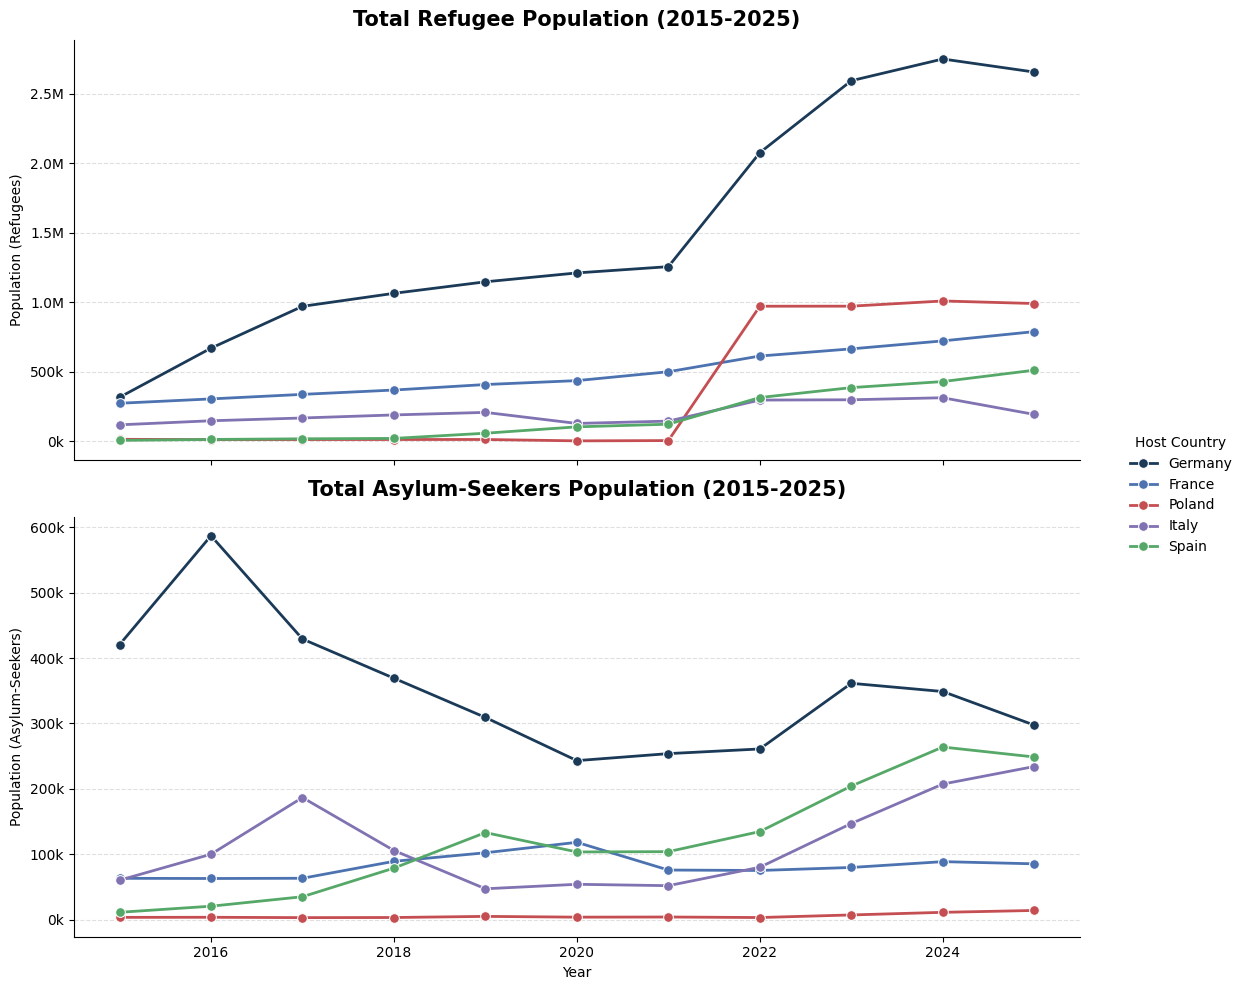

In [20]:
#group by
df_refugees_grouped = (
    df_eu
    .groupby(['Year', 'Country of Asylum'])['Refugees']
    .sum()
    .reset_index()
)

df_seekers_grouped = (
    df_eu
    .groupby(['Year', 'Country of Asylum'])['Asylum-seekers']
    .sum()
    .reset_index()
)

#subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

#order
sns.lineplot(
    data=df_refugees_grouped,
    x='Year',
    y='Refugees',
    hue='Country of Asylum',
    hue_order=legend_order,       
    palette=custom_palette,       
    linewidth=2.0,
    marker='o',
    markersize=7,
    ax=ax1                        
)

ax1.set_title('Total Refugee Population (2015-2025)', fontsize=15, weight='bold', pad=10)
ax1.set_ylabel('Population (Refugees)')
ax1.set_xlabel('')               
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
ax1.get_legend().remove()        

#plot
sns.lineplot(
    data=df_seekers_grouped,
    x='Year',
    y='Asylum-seekers',
    hue='Country of Asylum',
    hue_order=legend_order,
    palette=custom_palette,
    linewidth=2.0,
    marker='o',
    markersize=7,
    ax=ax2                        
)

ax2.set_title('Total Asylum-Seekers Population (2015-2025)', fontsize=15, weight='bold', pad=15)
ax2.set_ylabel('Population (Asylum-Seekers)')
ax2.set_xlabel('Year')          
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))

#one legend
handles, labels = ax2.get_legend_handles_labels()
ax2.get_legend().remove()

#layout
sns.despine()

#legend
fig.legend(
    handles, 
    labels, 
    title='Host Country',
    bbox_to_anchor=(1.02, 0.5),   
    loc='center left',
    frameon=False
)

plt.tight_layout()

#save
plt.savefig(
    "Figure 8 - Refugees and Asylum Seekers Stacked.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

In [21]:
from pandas_datareader import wb

#filter UNHCR data for 2025
df_2025 = df[(df['Country of Asylum'].isin(eu_countries)) & (df['Year'] == 2025)].copy()

#clean numeric types for UNHCR tracking, fill NaN with '0'
df_2025['Refugees'] = pd.to_numeric(df_2025['Refugees'], errors='coerce').fillna(0)
df_2025['Asylum-seekers'] = pd.to_numeric(df_2025['Asylum-seekers'], errors='coerce').fillna(0)

#calculate absolute Total stock per row
df_2025['Total'] = df_2025['Refugees'] + df_2025['Asylum-seekers']

#aggregate total stock per host country for 2025
df_unhcr_2025 = df_2025.groupby('Country of Asylum')['Total'].sum().reset_index()

#define ISO code for top 10 for fetching World Bank structural data
iso_mapping = {
    'Germany': 'DE',
    'Poland': 'PL',
    'France': 'FR',
    'Spain': 'ES',
    'Italy': 'IT',
    'Czechia': 'CZ',
    'Netherlands': 'NL',
    'Austria': 'AT',
    'Belgium': 'BE',
    'Romania': 'RO'
}
eu_iso_codes = list(iso_mapping.values())

#download World Bank data
##fetch GDP (current USD) and Total Population using the correct lowercase function
###using 2023 as the consolidated structural baseline to ensure full World Bank data availability
print('Downloading World Bank structural metrics (GDP & Population via wb.download)...')
df_wb_gdp = wb.download(indicator='NY.GDP.MKTP.CD', country=eu_iso_codes, start=2025, end=2025).reset_index()
df_wb_pop = wb.download(indicator='SP.POP.TOTL', country=eu_iso_codes, start=2025, end=2025).reset_index()

#merge World Bank structural metrics
df_wb = pd.merge(df_wb_gdp, df_wb_pop, on=['country', 'year'])
df_wb.columns = ['Country_WB', 'Year_WB', 'GDP_USD', 'Total_Population']

#map World Bank country labels dynamically to match UNHCR string format
df_wb['Country of Asylum'] = df_wb['Country_WB'].map(
    lambda x: 
        'Germany' if 'Germany' in x else
        'Poland' if 'Poland' in x else
        'France' if 'France' in x else
        'Spain' if 'Spain' in x else
        'Italy' if 'Italy' in x else
        'Czechia' if ('Czech' in x or 'Czechia' in x) else
        'Netherlands' if 'Netherlands' in x else
        'Austria' if 'Austria' in x else
        'Belgium' if 'Belgium' in x else
        'Romania' if 'Romania' in x else
        None
)

#convert raw GDP into Billions for cleaner KPI scaling
df_wb['GDP_Billions'] = df_wb['GDP_USD'] / 1_000_000_000

#merge UNHCR metric tracking with economic and demographic indicators
df_burden = pd.merge(df_unhcr_2025, df_wb[['Country of Asylum', 'GDP_Billions', 'Total_Population']], on='Country of Asylum')

#compute normalized Burden KPIs
##KPI1: Societal Intake Density (Total Displaced Persons per 1,000 Inhabitants)
df_burden['Displaced_per_1k_Pop'] = df_burden['Total'] / (df_burden['Total_Population'] / 1000)

##KPI2: Economic Burden Capacity (Total Displaced Persons per 1 Billion USD of GDP)
df_burden['Displaced_per_Billion_GDP'] = df_burden['Total'] / df_burden['GDP_Billions']

#sort by relative societal density to expose institutional policy disparities
df_burden = df_burden.sort_values(by='Displaced_per_1k_Pop', ascending=False)

#save to csv
df_burden.to_csv('eu_displacement_burden_2025.csv', index=False)

#pint summary table
print('\n NORMALIZED EU DISPLACEMENT BURDEN ANALYSIS (CROSS-SECTIONAL SNAPSHOT)')
print('-' * 95)
print(f'{'Country of Asylum':<15} | {'Absolute Total':<15} | {'Per 1,000 Pop':<15} | {'Per $1B GDP':<15}')
for idx, row in df_burden.iterrows():
    print(f'{row['Country of Asylum']:<15} | {row['Total']:<15,.0f} | {row['Displaced_per_1k_Pop']:<15.2f} | {row['Displaced_per_Billion_GDP']:<15.2f}')


 NORMALIZED EU DISPLACEMENT BURDEN ANALYSIS (CROSS-SECTIONAL SNAPSHOT)
-----------------------------------------------------------------------------------------------
Country of Asylum | Absolute Total  | Per 1,000 Pop   | Per $1B GDP    
Czechia         | 396,552         | 36.42           | 1014.13        
Germany         | 2,952,694       | 35.37           | 584.59         
Austria         | 308,665         | 33.52           | 532.67         
Poland          | 1,004,317       | 27.56           | 969.89         
Belgium         | 245,118         | 20.53           | 337.88         
Netherlands     | 333,597         | 18.44           | 250.30         
Spain           | 759,794         | 15.39           | 398.54         
France          | 873,646         | 12.71           | 259.53         
Romania         | 206,987         | 10.88           | 482.85         
Italy           | 427,058         | 7.25            | 167.37         


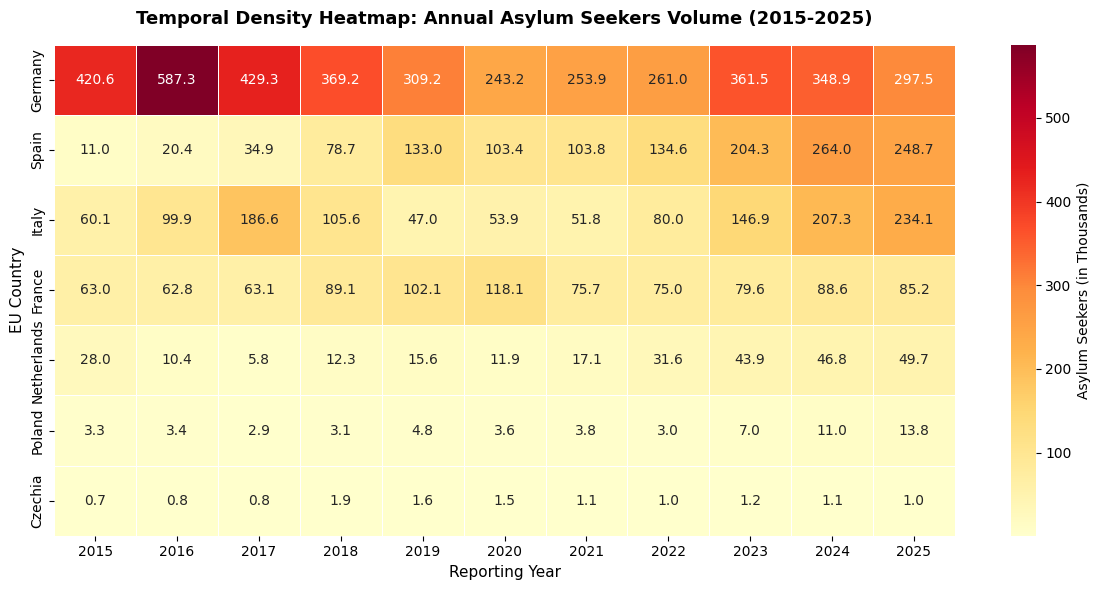

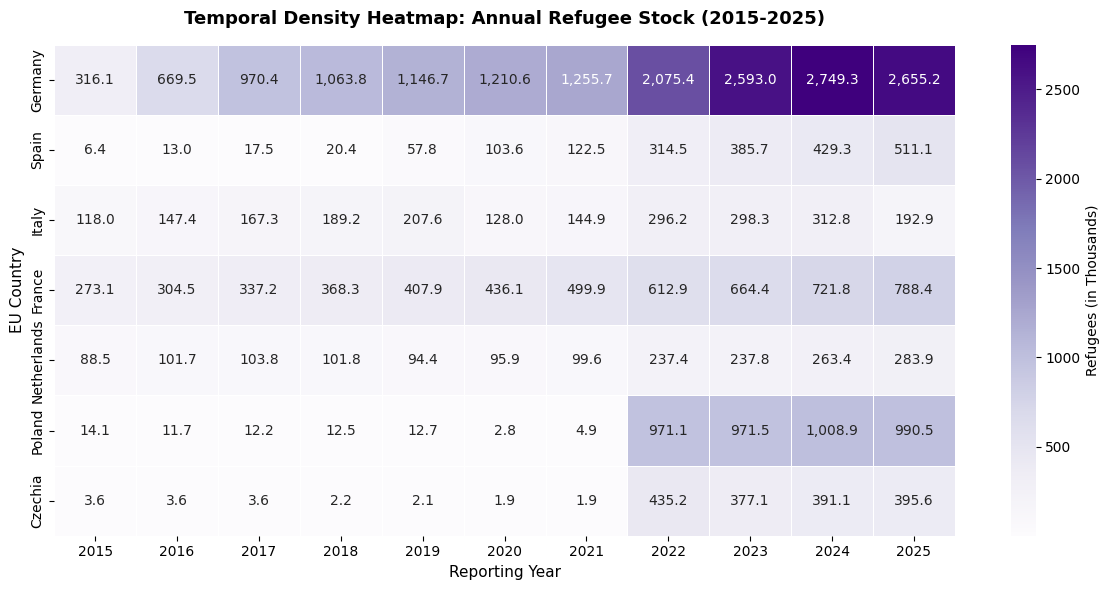

In [22]:
#top 7
df.columns = df.columns.str.strip()
eu_countries_7 = ['Germany', 'Poland', 'France', 'Spain', 'Italy', 'Czechia', 'Netherlands']
df_heatmap_eu = df[(df['Country of Asylum'].isin(eu_countries_7)) & (df['Year'] >= 2015) & (df['Year'] <= 2025)].copy()

#datatyp
df_heatmap_eu['Asylum-seekers'] = pd.to_numeric(df_heatmap_eu['Asylum-seekers'], errors='coerce').fillna(0)
df_heatmap_eu['Refugees'] = pd.to_numeric(df_heatmap_eu['Refugees'], errors='coerce').fillna(0)

#group by
df_trend = df_heatmap_eu.groupby(['Year', 'Country of Asylum'])[['Asylum-seekers', 'Refugees']].sum().reset_index()

#divide by 1000
df_trend['Asylum_Thousands'] = df_trend['Asylum-seekers'] / 1000
df_trend['Refugees_Thousands'] = df_trend['Refugees'] / 1000

#pivot tables
pivot_asylum = df_trend.pivot(index='Country of Asylum', columns='Year', values='Asylum_Thousands')
pivot_refugees = df_trend.pivot(index='Country of Asylum', columns='Year', values='Refugees_Thousands')

#sort in descending order
country_order = df_trend.groupby('Country of Asylum')['Asylum-seekers'].sum().sort_values(ascending=False).index
pivot_asylum = pivot_asylum.reindex(country_order)
pivot_refugees = pivot_refugees.reindex(country_order)

#heatmap 1
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_asylum, 
    annot=True,              
    fmt=",.1f",             
    cmap='YlOrRd',           
    linewidths=0.5, 
    cbar_kws={'label': 'Asylum Seekers (in Thousands)'}
)
plt.title('Temporal Density Heatmap: Annual Asylum Seekers Volume (2015-2025)', fontsize=13, pad=15, weight='bold')
plt.xlabel('Reporting Year', fontsize=11)
plt.ylabel('EU Country', fontsize=11)
plt.tight_layout()
plt.show()

#heatmap 2
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_refugees, 
    annot=True, 
    fmt=",.1f",            
    cmap='Purples',          
    linewidths=0.5, 
    cbar_kws={'label': 'Refugees (in Thousands)'}
)

#title
plt.title('Temporal Density Heatmap: Annual Refugee Stock (2015-2025)', fontsize=13, pad=15, weight='bold')
plt.xlabel('Reporting Year', fontsize=11)
plt.ylabel('EU Country', fontsize=11)
plt.tight_layout()

#save
plt.savefig(
    "Figure 9 - Heatmaps Asylum Seekers and Refugees.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

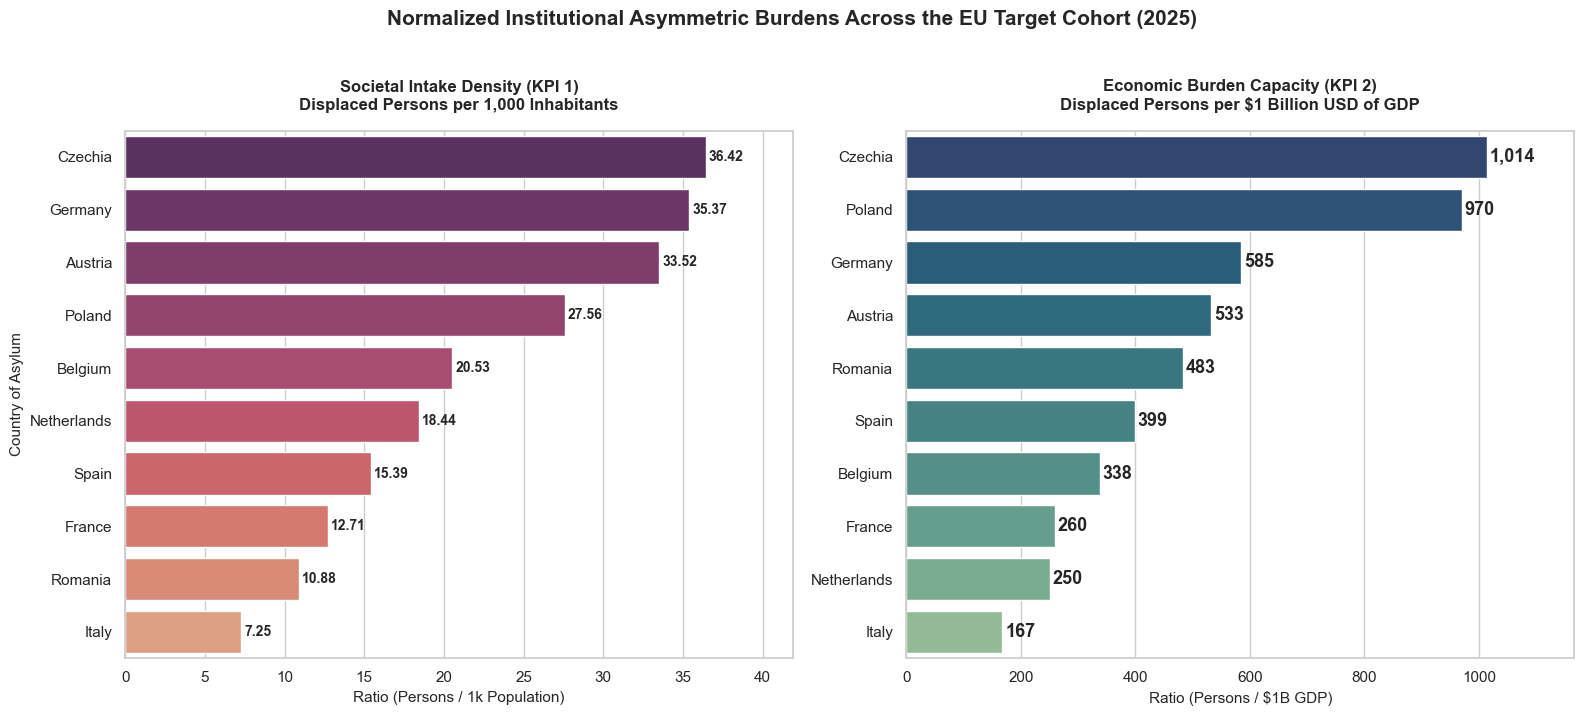

In [23]:
#layout
sns.set_theme(style="whitegrid")

#subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

#sort
df_plot1 = df_burden.sort_values(by='Displaced_per_1k_Pop', ascending=False)

#sort
df_plot2 = df_burden.sort_values(by='Displaced_per_Billion_GDP', ascending=False)

#KPI 1
sns.barplot(
    x='Displaced_per_1k_Pop', 
    y='Country of Asylum', 
    data=df_plot1, 
    ax=ax1, 
    palette= 'flare_r',
    hue='Country of Asylum',
    legend=False
)

#labels
for p in ax1.patches:
    width = p.get_width()
    ax1.text(
        width + 0.2, 
        p.get_y() + p.get_height()/2, 
        f'{width:.2f}', 
        va='center', 
        fontsize=10, 
        weight='bold'
    )

ax1.set_title('Societal Intake Density (KPI 1)\nDisplaced Persons per 1,000 Inhabitants', fontsize=12, pad=15, weight='bold')
ax1.set_xlabel('Ratio (Persons / 1k Population)', fontsize=11)
ax1.set_ylabel('Country of Asylum', fontsize=11)

#KPI 2
sns.barplot(
    x='Displaced_per_Billion_GDP', 
    y='Country of Asylum', 
    data=df_plot2, 
    ax=ax2, 
    palette= 'crest_r',    
    hue='Country of Asylum',
    legend=False
)

#labels
for p in ax2.patches:
    width = p.get_width()
    ax2.text(
        width + 5, 
        p.get_y() + p.get_height()/2, 
        f'{width:,.0f}',     
        va='center', 
        fontsize=13, 
        weight='bold'
    )

ax2.set_title('Economic Burden Capacity (KPI 2)\nDisplaced Persons per $1 Billion USD of GDP', fontsize=12, pad=15, weight='bold')
ax2.set_xlabel('Ratio (Persons / $1B GDP)', fontsize=11)
ax2.set_ylabel('')

#layout
plt.suptitle(
    'Normalized Institutional Asymmetric Burdens Across the EU Target Cohort (2025)', 
    fontsize=15, 
    weight='bold', 
    y=1.02
)

#axes
ax1.set_xlim(0, df_burden['Displaced_per_1k_Pop'].max() * 1.15)
ax2.set_xlim(0, df_burden['Displaced_per_Billion_GDP'].max() * 1.15)

plt.tight_layout()

#save
plt.savefig(
    "Figure 10 - Normalized Burden.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

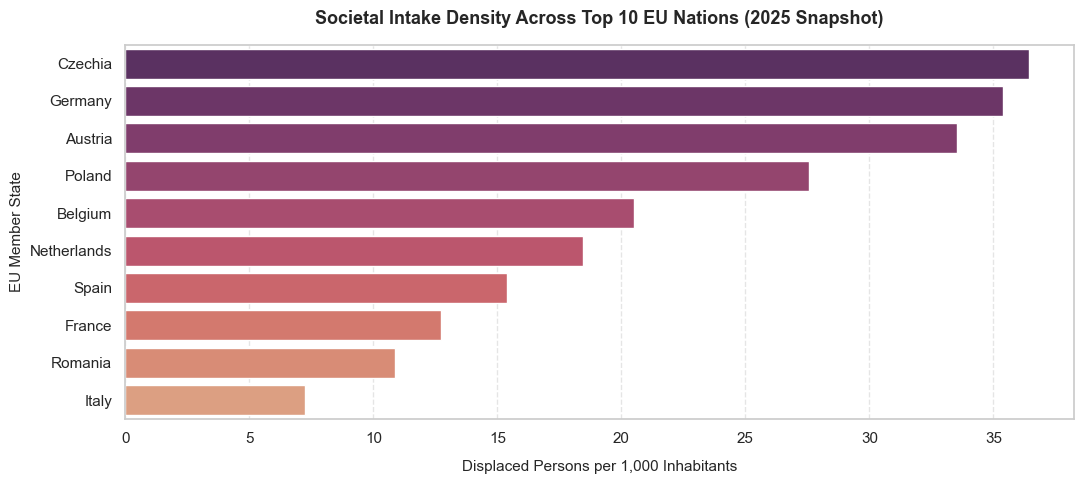

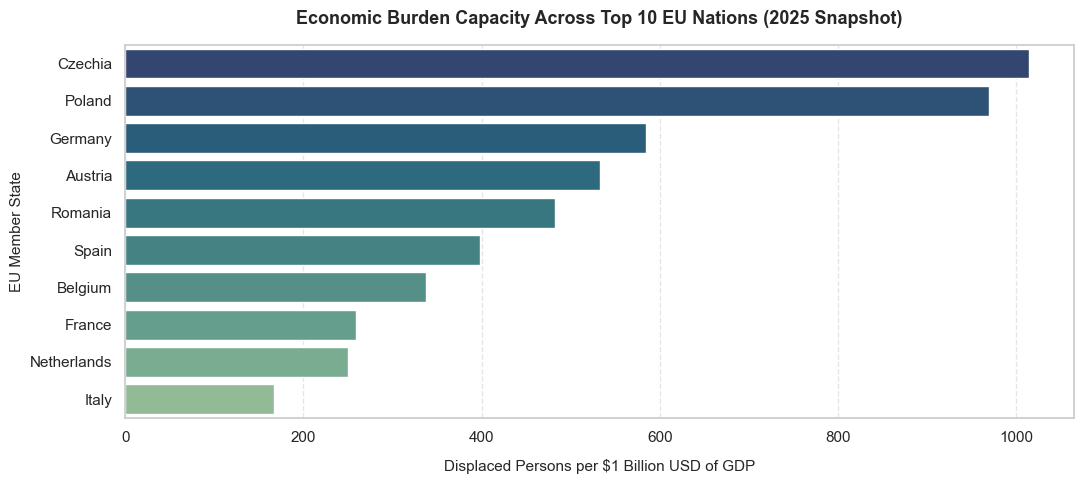

In [24]:
#define style
sns.set_theme(style="whitegrid")

#Plot 1: Social Intake Density
##sort by social burden (number of people)
df_plot1 = df_burden.sort_values(by='Displaced_per_1k_Pop', ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=df_plot1,
    y='Country of Asylum',
    x='Displaced_per_1k_Pop',
    hue='Country of Asylum',
    palette='flare_r',
    legend=False
)

plt.title('Societal Intake Density Across Top 10 EU Nations (2025 Snapshot)', fontsize=13, pad=15, weight='bold')
plt.xlabel('Displaced Persons per 1,000 Inhabitants', fontsize=11, labelpad=10)
plt.ylabel('EU Member State', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Plot 2: Economic Burden Capacity
##sort by economic burden
df_plot2 = df_burden.sort_values(by='Displaced_per_Billion_GDP', ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=df_plot2,
    y='Country of Asylum',
    x='Displaced_per_Billion_GDP',
    hue='Country of Asylum',
    palette='crest_r',
    legend=False
)

#title
plt.title('Economic Burden Capacity Across Top 10 EU Nations (2025 Snapshot)', fontsize=13, pad=15, weight='bold')
plt.xlabel('Displaced Persons per $1 Billion USD of GDP', fontsize=11, labelpad=10)
plt.ylabel('EU Member State', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

#save (not used in assignment)
plt.savefig(
    "Figure xx - Social Intake Density.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

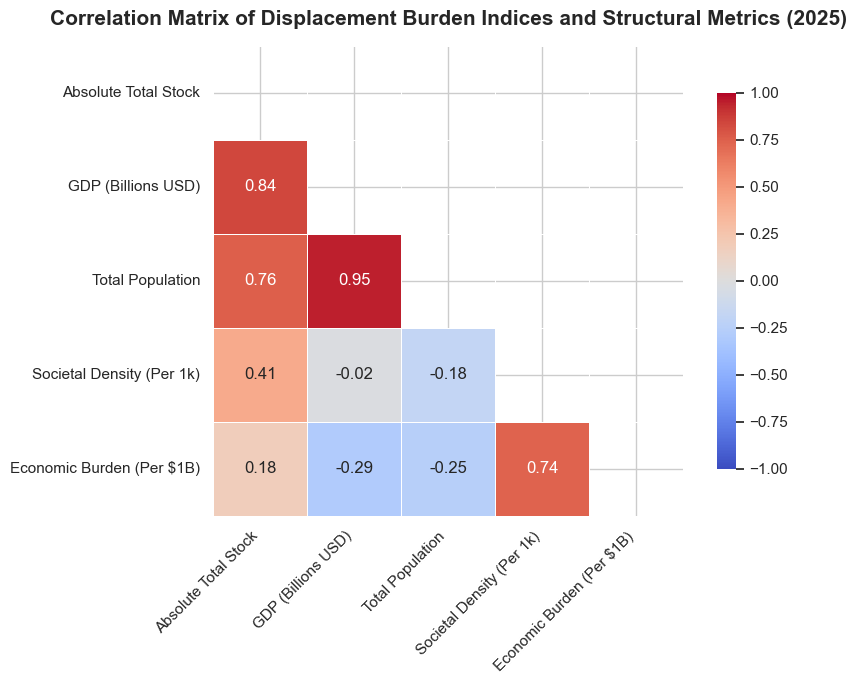

In [25]:
#numeric features for heatmap
features_for_heatmap = [
    'Total', 
    'GDP_Billions', 
    'Total_Population', 
    'Displaced_per_1k_Pop', 
    'Displaced_per_Billion_GDP'
]

#correlation matrix
corr_matrix = df_burden[features_for_heatmap].corr()

#labels
labels_clean = [
    'Absolute Total Stock',
    'GDP (Billions USD)',
    'Total Population',
    'Societal Density (Per 1k)',
    'Economic Burden (Per $1B)'
]

#cut of the upper halve to avoid redundances (Tufte)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

#size
plt.figure(figsize=(9, 7))

#plot
sns.heatmap(
    corr_matrix,
    mask=mask,                  
    annot=True,                 
    fmt=".2f",                  
    cmap='coolwarm',           
    vmin=-1, vmax=1,            
    square=True,               
    linewidths=0.5,             
    cbar_kws={"shrink": 0.8},   
    xticklabels=labels_clean,
    yticklabels=labels_clean
)

#layout
plt.title('Correlation Matrix of Displacement Burden Indices and Structural Metrics (2025)', fontsize=15, pad=15, weight='bold')

#axes
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

#save
plt.savefig(
    "Figure 11 - Correlation Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

#show plot
plt.show()

In [26]:
#end